# The Articulation Story — §4.1–4.3 (v2, plain-language)
*2026-08-10 — rebuilt to the requested spec. All data local in `outputs/articulation_story_20260810/`.*

**Glossary (the jargon, defined once):**
- **unit** — one reusable prompt instruction mined by an optimizer (the Ω pool that powers Table 1). 366 units across the five benchmarks, each blind-labeled MECHANICAL (checkable by code) / STRUCTURAL_CRAFT (needs semantic checking) / TASTE (subjective).
- **channel / text-segment category** — which *part* of an articulation the judge model sees: `name` (just the metric's name), `definition` (its written definition), `definition_padded` (definition + filler, length control), `explanation` (longer explanation), `dossier` (full rich writeup), `dossier_mismatched` (a *different* metric's dossier — placebo).
- **functional** — the 'show, don't tell' arm: the metric's **name + selected example texts** (positives and negatives chosen by search to make a 70B judge match a reference). No definition text at all.
- **receiver / judge capacity (z)** — the capability of the model *reading* the articulation and judging texts with it, from 1B to 72B local models up to frontier (GLM-5.2, gpt-oss-120b). 'z' is just this axis.
- **recovery** — balanced accuracy of that judge's yes/no verdicts against the reference (majority of 4 strong models' dossier-informed verdicts). Chance = .50.
- *(selection detail you can ignore: 'frontier' vs 'encoder' names which reference the example-search optimized against — a 4-model consensus vs qwen25-72b alone. Curves are shown for one and the results agree.)*

**Reading rules:** notebook recomputations use all 300 probes (exploratory); canonical numbers = the artifacts indexed at the bottom. News appears only panel-internally. Placebo-matched cells are anchoring, never content.

In [1]:
import glob, json, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review"]
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
PARAMS = {"llama1b":1e9,"llama3b":3e9,"qwen25-3b":3e9,"qwen25-7b":7e9,"llama8b":8e9,
          "qwen25-14b":14e9,"gemma2-27b":27e9,"qwen25-32b":32e9,"llama70b":70e9,
          "qwen25-72b":72e9}
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in TASKS}
GLM = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in TASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLM[task].get("glm-47", {}), GLM[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
print("panels loaded")

panels loaded


## 4.1 How much of what optimizers mine is actually codable?

Per benchmark: the % of its Ω prompt-units that a certified blind tagger (6/6 anchors) labeled **MECHANICAL** — i.e., successfully checkable by code. STRUCTURAL_CRAFT needs semantic judgment; TASTE is subjective.

Construct-metric side (for context): the banks' metrics have no pre-enumerated unit lists, so per-construct codability is represented by the **mechbat** subsets — constructs whose truth *was* implemented in code: 18/246 humor (7%), 20/60 peer-review (33%). The overall composition finding (ledger HB172): Ω pools are 292 CRAFT / 68 MECH / **0 TASTE** — optimizers mine checkable-adjacent material and never mine taste.

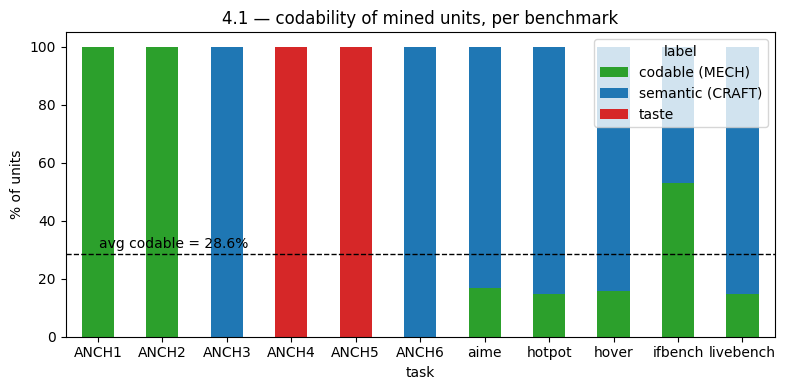

average % codable across tasks: 28.6%


label,MECHANICAL,STRUCTURAL_CRAFT,TASTE,n,pct_codable
task,,,,,
ANCH1,1,0,0,1,100.0
ANCH2,1,0,0,1,100.0
ANCH3,0,1,0,1,0.0
ANCH4,0,0,1,1,0.0
ANCH5,0,0,1,1,0.0
ANCH6,0,1,0,1,0.0
aime,8,40,0,48,16.7
hotpot,10,58,0,68,14.7
hover,26,138,0,164,15.9


In [2]:
labs = json.load(open("../datasets/prompt-optimality-test/runs/omega_unit_labels_checkability.json"))["labels"]
rows = []
for k, v in labs.items():
    task = k.split(":")[0]
    rows.append({"task": task, "label": v["label"]})
dfu = pd.DataFrame(rows)
pct = dfu.groupby("task")["label"].value_counts(normalize=True).unstack(fill_value=0) * 100
pct = pct.rename(columns={"MECHANICAL": "codable (MECH)", "STRUCTURAL_CRAFT": "semantic (CRAFT)", "TASTE": "taste"})
ax = pct[["codable (MECH)", "semantic (CRAFT)"] + (["taste"] if "taste" in pct else [])].plot(
    kind="bar", stacked=True, figsize=(8, 4), color=["#2ca02c", "#1f77b4", "#d62728"])
avg = pct["codable (MECH)"].mean()
ax.axhline(avg, color="k", ls="--", lw=1)
ax.text(0.02, avg + 2, f"avg codable = {avg:.1f}%", fontsize=10)
ax.set_ylabel("% of units"); ax.set_title("4.1 — codability of mined units, per benchmark")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
counts = dfu.groupby("task")["label"].value_counts().unstack(fill_value=0)
counts["n"] = counts.sum(1)
counts["pct_codable"] = (counts.get("MECHANICAL", 0) / counts["n"] * 100).round(1)
print(f"average % codable across tasks: {counts['pct_codable'].mean():.1f}%")
counts

## 4.2 Which parts of the prompt matter — distribution view

Box plots of **per-metric recovery** for each text-segment category (judge = llama70b, the strongest local receiver; real constructs only, planted excluded), then per-metric **gain over the bare name** — how much each richer segment adds.

Certified summary: gains are content, not length (`definition_padded` ≈ `definition`; the mismatched-dossier placebo sits at floor). The MI census adds the economics: `name` is talkative but uninformative; `dossier` is decisive — most likely to collapse to a constant answer (degenerate), but the most information-efficient when it varies.

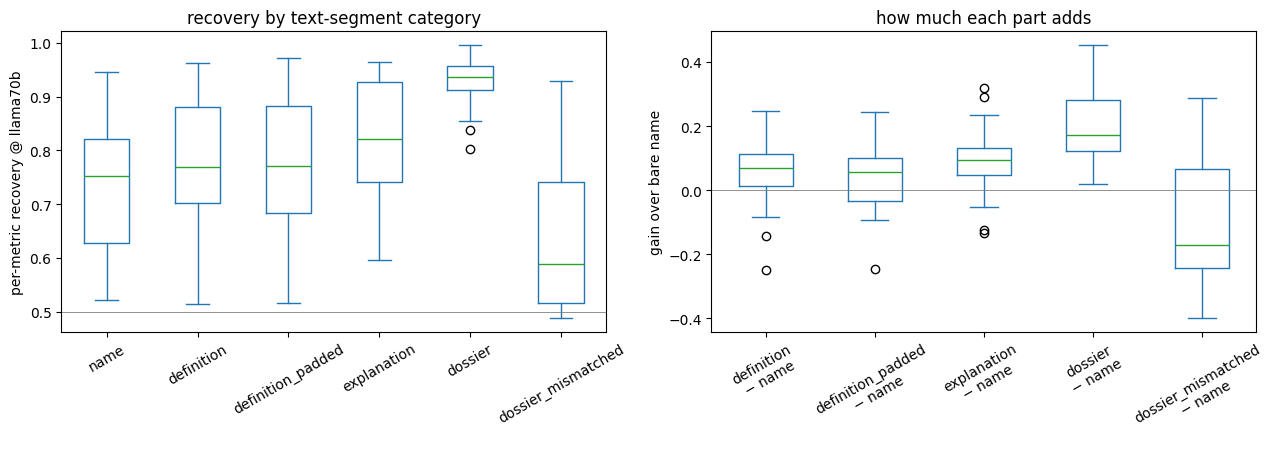

,name,definition,definition_padded,explanation,dossier,dossier_mismatched
mean,0.731,0.787,0.768,0.819,0.928,0.638
50%,0.752,0.770,0.770,0.822,0.936,0.589


In [3]:
ARMS = ["name", "definition", "definition_padded", "explanation", "dossier", "dossier_mismatched"]
recs = []
for t in TASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        row = {"task": t, "base": b}
        for arm in ARMS:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: row[arm] = y
        if "name" in row and "dossier" in row: recs.append(row)
df42 = pd.DataFrame(recs)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
df42[ARMS].plot(kind="box", ax=axes[0], rot=30)
axes[0].axhline(.5, color="gray", lw=.6)
axes[0].set_ylabel("per-metric recovery @ llama70b"); axes[0].set_title("recovery by text-segment category")
gains = df42[["definition","definition_padded","explanation","dossier","dossier_mismatched"]].sub(df42["name"], axis=0)
gains.columns = [c + "\n− name" for c in gains.columns]
gains.plot(kind="box", ax=axes[1], rot=30)
axes[1].axhline(0, color="gray", lw=.6)
axes[1].set_ylabel("gain over bare name"); axes[1].set_title("how much each part adds")
plt.tight_layout(); plt.show()
df42[ARMS].describe().loc[["mean","50%"]].round(3)

## 4.2a Examples vs definitions — and why the judging model matters

**The arms:** `definition` = show the judge the metric's written definition. `functional` = show the judge the metric's **name + hand-picked example texts** (chosen by search so a 70B judge matches the reference) — examples *instead of* a definition.

**Where examples beat the definition:** on the contested slate, at the very receivers that picked the examples — 16 distinct metrics win by ≥+.05, and the winners are gestalt 'show-don't-tell' constructs (cringe calibration, surprise/misdirection, imagery, one-liner timing). Table below.

**Why the receiver being a different model matters — three receivers, same example sets:**
| receiver | what happens to *any* appended examples | construct-specific content |
|---|---|---|
| llama70b (the selector) | examples beat the definition on the win-list metrics | real (null-controlled, +.03\*) |
| qwen25-72b (different family, well-calibrated) | appended examples **hurt** on average (−.13\*) | small but real (+.013\*) |
| gpt-oss-120b (frontier) | *any* examples help (+.06\*) — because its definition-reading collapses to NO and examples re-calibrate it — but swapped-in examples from a *different* metric help equally: **anchoring, not content** | none on average |

So the value of showing examples is a property of the **construct–listener pair**: the same example set is a win, a harm, or a placebo depending on who reads it. The one construct family whose example-content travels across receivers: **norm-boundary metrics** (taste/offense-line constructs; blind-categorized, rank test p=.006/.0095, LOO-robust) — capped by the fact that even there examples rarely beat a ceiling-strong definition.

In [4]:
# examples-beat-definition wins (holdout, at the selecting receivers)
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "metric": base, "judge": s,
                                  "definition": h["definition"], "examples(functional)": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
best = (df70.sort_values("delta", ascending=False).groupby("metric").first()
        .sort_values("delta", ascending=False))
best[best.delta >= .05][["task", "judge", "definition", "examples(functional)", "delta"]]

,task,judge,definition,examples(functional),delta
metric,,,,,
"Compressed, quotable phrasing",humor,llama70b,0.5511,0.8114,0.260
"Surprise, misdirection, and dual‑read clarity",humor,llama70b,0.6706,0.9059,0.235
"Delivery, timing, and commitment",humor,qwen25-72b,0.7361,0.9618,0.226
"Surprise, incongruity, and misdirection mechanics",humor,llama70b,0.6791,0.9002,0.221
Economy and Precision of Prose,creative_writing,llama70b,0.5718,0.7719,0.200
Observational/everyday‑life humor,humor,llama70b,0.6808,0.8808,0.200
Shared knowledge and reference accessibility,humor,qwen25-72b,0.5728,0.7529,0.180
Concrete imagery and vivid specificity,humor,llama70b,0.7491,0.9239,0.175
Cringe/awkwardness calibrated,humor,llama70b,0.7751,0.9234,0.148


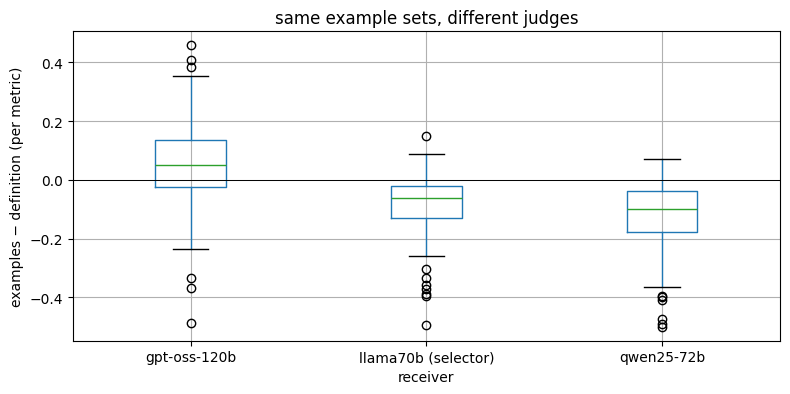

,examples_minus_definition,content(true - swapped)
receiver,,
gpt-oss-120b,0.0500,0.0
llama70b (selector),-0.0612,NaN
qwen25-72b,-0.0978,0.0


In [5]:
# same example sets, three judges: fun-def per receiver (bank scale where available)
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
rows = []
for rcv in ("qwen25-72b", "gpt-oss-120b"):
    for r in led[rcv]:
        rows.append({"receiver": rcv, "metric": r["b"],
                     "examples_minus_definition": r["functional"] - r["definition"],
                     "content(true - swapped)": r["functional"] - r["functionalmm"]})
v3h = json.load(open(f"{D}/flips/flip_functional_v3_llama70b.json"))["results"]["humor"]
for b, rec in v3h.items():
    h = rec["objectives"].get("frontier2v", {}).get("holdout", {})
    if h.get("functional") is not None and h.get("definition") is not None:
        rows.append({"receiver": "llama70b (selector)", "metric": b,
                     "examples_minus_definition": h["functional"] - h["definition"],
                     "content(true - swapped)": np.nan})
dfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4.2))
dfr.boxplot(column="examples_minus_definition", by="receiver", ax=ax)
ax.axhline(0, color="k", lw=.7); ax.set_ylabel("examples − definition (per metric)")
ax.set_title("same example sets, different judges"); plt.suptitle("")
plt.tight_layout(); plt.show()
dfr.groupby("receiver")[["examples_minus_definition", "content(true - swapped)"]].median().round(4)

## 4.3 Scaling laws — recovery vs judge capacity

Absolute recovery curves against **model capacity** (log parameters), per family (Llama, Qwen2.5) and per text-segment category, with frontier reference points. This is the axis previously called 'receiver z'.

Certified structure: recovery rises with capacity for every channel; the ordering (dossier ≥ explanation ≥ definition ≥ name ≫ placebo) is stable across the ladder; 69/1032 constructs are still gaining at the top of *all* families (asymptote unknown — and not de-censorable against the local-dialect reference: the frontier listener shows healthy variance but lower agreement, i.e. the ceiling belongs to the construct–listener pair).

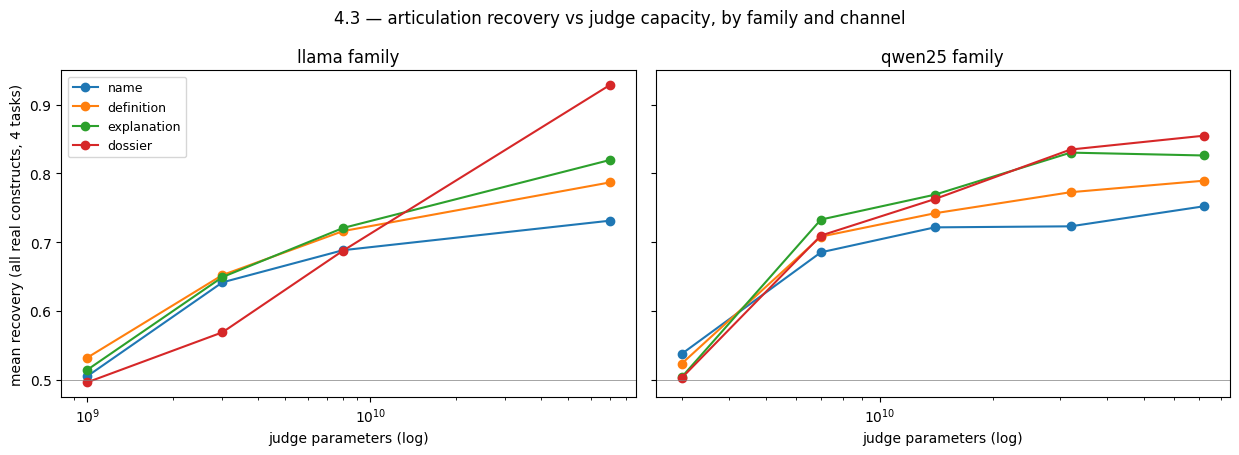

In [6]:
FAM = {"llama": ["llama1b","llama3b","llama8b","llama70b"],
       "qwen25": ["qwen25-3b","qwen25-7b","qwen25-14b","qwen25-32b","qwen25-72b"]}
ARMS4 = ["name", "definition", "explanation", "dossier"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for ax, (fam, exs) in zip(axes, FAM.items()):
    for arm in ARMS4:
        xs, ys = [], []
        for ex in exs:
            vals = []
            for t in TASKS:
                for k in PAN[t].get(ex, {}):
                    b, a = k.rsplit("||", 1)
                    if a != arm or b.startswith("PLANTED"): continue
                    lab = ref_for(t, b)
                    if lab is None: continue
                    y = balanced(np.asarray(PAN[t][ex][k], float), lab)
                    if y is not None: vals.append(y)
            if vals:
                xs.append(PARAMS[ex]); ys.append(np.mean(vals))
        ax.semilogx(xs, ys, marker="o", label=arm)
    ax.set_title(f"{fam} family"); ax.set_xlabel("judge parameters (log)")
    ax.axhline(.5, color="gray", lw=.5)
axes[0].set_ylabel("mean recovery (all real constructs, 4 tasks)")
axes[0].legend(fontsize=9)
fig.suptitle("4.3 — articulation recovery vs judge capacity, by family and channel")
plt.tight_layout(); plt.show()

constructs still gaining at ladder-top in ALL 3 families: 69/1032


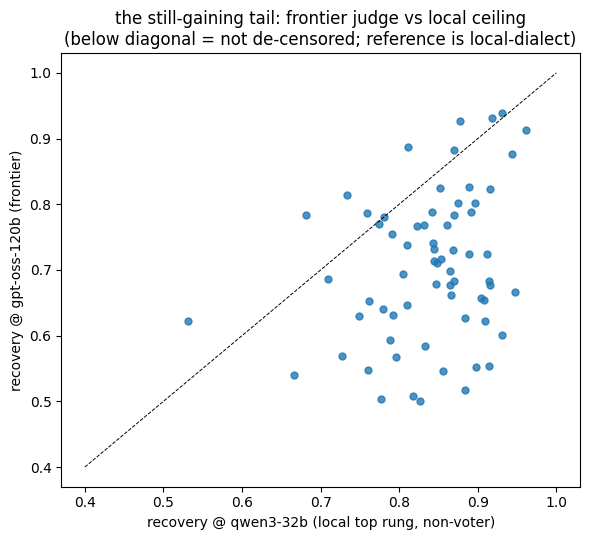

In [7]:
# the still-gaining tail + the de-censor outcome (frontier listener vs local ceiling)
fj = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))
tm = pd.DataFrame([{"task": r["task"], "name": r["name"], **{f"gain_{k}": v
                    for k, v in r["top_minus_mid"].items()}} for r in fj["full_rows"]])
gaining = tm[(tm.filter(like="gain_") > .02).all(axis=1)]
print(f"constructs still gaining at ladder-top in ALL 3 families: {len(gaining)}/{len(tm)}")
dec = pd.DataFrame(json.load(open(f"{D}/analyses/decensor_harvest_v1.json")))
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(dec["qwen3-32b"], dec["gptoss"], s=25, alpha=.8)
lims = [.4, 1.0]; ax.plot(lims, lims, "k--", lw=.7)
ax.set_xlabel("recovery @ qwen3-32b (local top rung, non-voter)")
ax.set_ylabel("recovery @ gpt-oss-120b (frontier)")
ax.set_title("the still-gaining tail: frontier judge vs local ceiling\n(below diagonal = not de-censored; reference is local-dialect)")
plt.tight_layout(); plt.show()

---
### Canonical artifacts (quote these, not notebook recomputations)
| claim | artifact |
|---|---|
| unit codability labels | `datasets/prompt-optimality-test/runs/omega_unit_labels_checkability.json` (ledger HB172) |
| channel MI/degeneracy economics | `analyses/mi_upper_census_v1.json`, `_v2.json` |
| examples ledgers (never merged) | `flips/flip_functional_v2_*.json` (fun−def wins) · `analyses/v3sets_ledger_v1.json` + `metric_categories_blind_v1.json` (content) |
| frontier limit cells w/ CIs | `analyses/frontier_limit_humor_v2.json` · math corroboration `analyses/glmexmath_harvest_v1.json` |
| examples-over-capacity curve | `analyses/flipladder_curve_v2_nonews.json` |
| staircases / census / de-censor | `analyses/family_verdict_join_v1.json`, `saturation_census_curve_v1.json`, `decensor_harvest_v1.json` |

Narrative + phrasing law: `notes/2026-08-05__direction12-battery-plan.md` · Table-1 ledger: `notes/2026-07-19__gepa-consolidation-and-momega-upgrade-plan.md`.